# 1- Class Activation Map with convolutions

In this first part, we will code class activation map as described in the paper [Learning Deep Features for Discriminative Localization](http://cnnlocalization.csail.mit.edu/)

There is a GitHub repo associated with the paper:
https://github.com/zhoubolei/CAM

And even a demo in PyTorch:
https://github.com/zhoubolei/CAM/blob/master/pytorch_CAM.py

The code below is adapted from this demo but we will not use hooks only convolutions...

In [ ]:
import io
import requests
from PIL import Image
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.nn import functional as F
import numpy as np
import cv2
from matplotlib.pyplot import imshow


# input image
LABELS_URL = 'https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json'
IMG_URL = 'https://raw.githubusercontent.com/zhoubolei/CAM/refs/heads/master/test.jpg'

As in the demo, we will use the Resnet18 architecture. In order to get CAM, we need to transform this network in a fully convolutional network: at all layers, we need to deal with images, i.e. with a shape $\text{Number of channels} \times W\times H$ . In particular, we are interested in the last images as shown here:
![](https://camo.githubusercontent.com/fb9a2d0813e5d530f49fa074c378cf83959346f7/687474703a2f2f636e6e6c6f63616c697a6174696f6e2e637361696c2e6d69742e6564752f6672616d65776f726b2e6a7067)

As we deal with a Resnet18 architecture, the image obtained before applying the `AdaptiveAvgPool2d` has size $512\times 7 \times 7$ if the input has size $3\times 224\times 224 $:
![resnet_Archi](https://pytorch.org/assets/images/resnet.png)

A- The first thing, you will need to do is 'removing' the last layers of the resnet18 model which are called `(avgpool)` and `(fc)`. Check that for an original image of size $3\times 224\times 224 $, you obtain an image of size $512\times 7\times 7$.

B- Then you need to retrieve the weights (and bias) of the `fc` layer, i.e. a matrix of size $1000\times 512$ transforming a vector of size 512 into a vector of size 1000 to make the prediction. Then you need to use these weights and bias to apply it pixelwise in order to transform your $512\times 7\times 7$ image into a $1000\times 7\times 7$ output (Hint: use a convolution). You can interpret this output as follows: `output[i,j,k]` is the logit for 'pixel' `[j,k]` for being of class `i`.

C- From this $1000\times 7\times 7$ output, check that you can retrieve the original output given by the `resnet18` by using an `AdaptiveAvgPool2d`. Can you understand why this is true?

D- In addition, you can construct the Class Activation Map. Draw the activation map for the class mountain bike, for the class lakeside.

## Validation:
1. make sure that when running your notebook, you display both CAM for the class mountain bike and for the class lakeside.
2. for question B above, what convolution did you use? Your answer, i.e. the name of the Pytorch layer with the correct parameters (in_channel,kernel...) here:

<span style="color:red">Replace by your answer</span>
3. your short explanation of why your network gives the same prediction as the original `resnet18`:

<span style="color:red">Replace by your answer</span>
4. Is your network working on an image which is not of size $224\times 224$, i.e. without resizing? and what about `resnet18`? Explain why?

<span style="color:red">Replace by your answer</span>

In [2]:
net = models.resnet18(pretrained=True)

c:\Users\a055963\git\ens-ml4sd\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\a055963\git\ens-ml4sd\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [3]:
net.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
x = torch.randn(5, 3, 224, 224)
y = net(x)
y.shape

torch.Size([5, 1000])

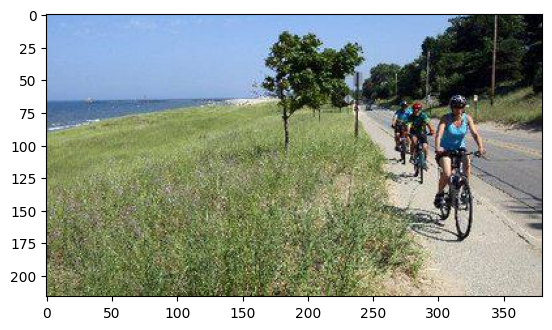

In [5]:
n_mean = [0.485, 0.456, 0.406]
n_std = [0.229, 0.224, 0.225]

normalize = transforms.Normalize(
   mean=n_mean,
   std=n_std
)
preprocess = transforms.Compose([
   transforms.Resize((224,224)),
   transforms.ToTensor(),
   normalize
])

# Display the image we will use.
response = requests.get(IMG_URL)
img_pil = Image.open(io.BytesIO(response.content))
imshow(img_pil);

In [6]:
img_tensor = preprocess(img_pil)
net = net.eval()
logit = net(img_tensor.unsqueeze(0))

In [7]:
logit.shape

torch.Size([1, 1000])

In [8]:
img_tensor.shape

torch.Size([3, 224, 224])

In [9]:
# download the imagenet category list
classes = {int(key):value for (key, value)
          in requests.get(LABELS_URL).json().items()}


def print_preds(logit):
    # print the predictions with their 'probabilities' from the logit
    h_x = F.softmax(logit, dim=1).data.squeeze()
    probs, idx = h_x.sort(0, True)
    probs = probs.numpy()
    idx = idx.numpy()
    # output the prediction
    for i in range(0, 5):
        print('{:.3f} -> {}'.format(probs[i], classes[idx[i]]))
    return idx

In [10]:
idx = print_preds(logit)

0.519 -> ['n03792782', 'mountain_bike']
0.124 -> ['n09193705', 'alp']
0.115 -> ['n02835271', 'bicycle-built-for-two']
0.104 -> ['n04509417', 'unicycle']
0.035 -> ['n09332890', 'lakeside']


In [11]:
def returnCAM(feature_conv, idx):
    # input: tensor feature_conv of dim 1000*W*H and idx between 0 and 999
    # output: image W*H with entries rescaled between 0 and 255 for the display
    cam = feature_conv[idx].detach().numpy()
    cam = cam - np.min(cam)
    cam_img = cam / np.max(cam)
    cam_img = np.uint8(255 * cam_img)
    return cam_img

In [12]:
#some utilities
def pil_2_np(img_pil):
    # transform a PIL image in a numpy array
    return np.asarray(img_pil)

def display_np(img_np):
    imshow(Image.fromarray(np.uint8(img_np)))
    
def plot_CAM(img_np, CAM):
    height, width, _ = img_np.shape
    heatmap = cv2.applyColorMap(cv2.resize(CAM,(width, height)), cv2.COLORMAP_JET)
    result = heatmap * 0.3 + img_np * 0.5
    display_np(result)

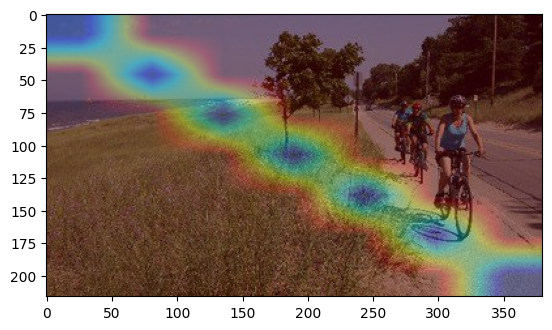

In [13]:
# here is a fake example to see how things work
img_np = pil_2_np(img_pil)
diag_CAM = returnCAM(torch.eye(7).unsqueeze(0),0)
plot_CAM(img_np,diag_CAM)

In [14]:
# Remove the last layers (avgpool and fc) to make it fully convolutional
layers = list(net.children())
last_fully_connected = layers[-1]
convolutional_layers = layers[:-2]

net_conv = nn.Sequential(*convolutional_layers)

In [ ]:
# Add the last fully connected layer as a 1x1 convolution
conv1d = torch.nn.Conv2d(in_channels=512, out_channels=1000, kernel_size=1)
print(f"{conv1d.weight.shape=}")
conv1d.weight = torch.nn.Parameter(last_fully_connected.weight.unsqueeze(-1).unsqueeze(-1))
conv1d.bias = torch.nn.Parameter(last_fully_connected.bias)
net_conv = nn.Sequential(net_conv, conv1d)

conv1d.weight.shape=torch.Size([1000, 512, 1, 1])


In [ ]:
# do not forget:
net_conv = net_conv.eval()

In [17]:
# to test things are right
x = torch.randn(5, 3, 224, 224)
y = net_conv(x)
y.shape

torch.Size([5, 1000, 7, 7])

In [18]:
logit_conv = net_conv(img_tensor.unsqueeze(0))

In [19]:
logit_conv.shape

torch.Size([1, 1000, 7, 7])

In [ ]:
# transform this to a [1,1000] tensor with AdaptiveAvgPool2d
adap = nn.AdaptiveAvgPool2d((1, 1))
logit_new = adap(logit_conv)

In [ ]:
# check that the outputs are the same
idx = print_preds(logit_new)

0.519 -> ['n03792782', 'mountain_bike']
0.124 -> ['n09193705', 'alp']
0.115 -> ['n02835271', 'bicycle-built-for-two']
0.104 -> ['n04509417', 'unicycle']
0.035 -> ['n09332890', 'lakeside']


In [22]:
{value[1]:key for key,value in classes.items()}["mountain_bike"]

671

In [23]:
{value[1]:key for key,value in classes.items()}["lakeside"]

975

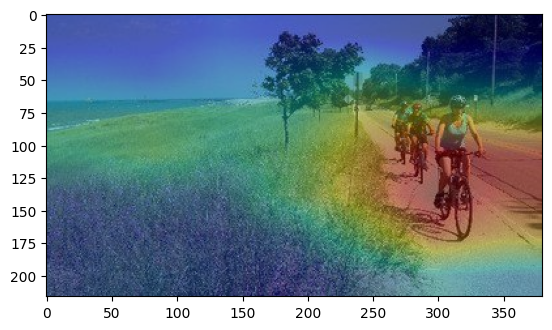

In [24]:
i = 975
CAM1 = returnCAM(logit_conv.squeeze(),idx[i])
plot_CAM(img_np,CAM1)

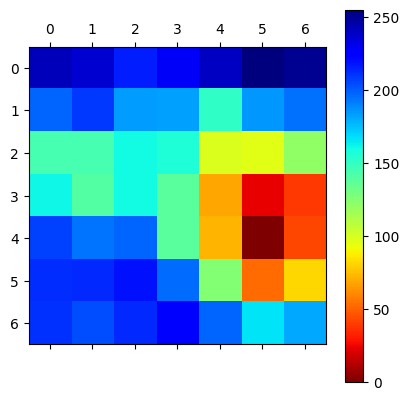

In [25]:
import matplotlib.pyplot as plt
plt.matshow(CAM1, cmap='jet_r')
plt.colorbar()

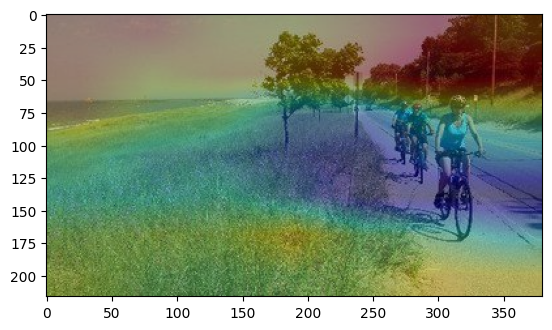

In [26]:
i = 671
CAM2 = returnCAM(logit_conv.squeeze(),idx[i])
plot_CAM(img_np,CAM2)

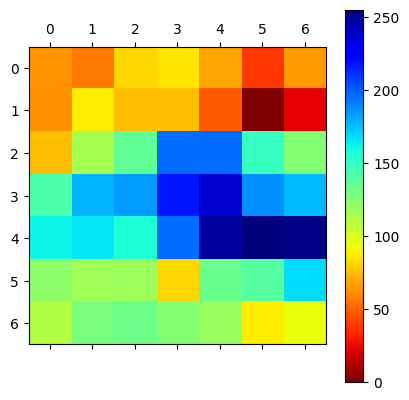

In [27]:
import matplotlib.pyplot as plt
plt.matshow(CAM2, cmap='jet_r')
plt.colorbar()